<a href="https://colab.research.google.com/github/isgandarjafarli/synthetic-to-real-mnist/blob/main/milestone1_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Synthetic-to-Real Digits Transfer Learning on MNIST

## Project Goal

**Research Question:** Can a convolutional neural network (CNN) trained exclusively on synthetically generated digit images accurately classify real handwriten digits from the MNIST dataset?

This project investigates whether models can learn useful features from artificial training data (specifically made to look bad) and successfully transfer them to real-world images. I tested this in my proto-experiment by:
1. Generating synthetic MNIST-like digits using simple geometric primitives
2. Training a CNN exclusively on synthetic data
3. Evaluating performance on real MNIST test set
4. Analyzing what works and what doesn't

:D 🇦

---

## Setup and Imports

In [1]:
# installing all required packages
!pip install torch torchvision tqdm matplotlib numpy pillow scikit-learn

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
from tqdm import tqdm

# setting random seeds
torch.manual_seed(42)
np.random.seed(42)

# checking devices via torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## Load Project Modules

If you are running on Colab, you may as well clone the GitHub repository first:

In [3]:
#for Google Colab - clone repository
import os
if not os.path.exists('synthetic_data.py'):
    !git clone https://github.com/isgandarjafarli/synthetic-to-real-mnist.git
    %cd synthetic-to-real-mnist

Cloning into 'synthetic-to-real-mnist'...
remote: Enumerating objects: 8, done.
remote: Counting objects: 100% (8/8), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 8 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (8/8), 12.60 KiB | 12.60 MiB/s, done.
/content/synthetic-to-real-mnist


In [4]:
# immporting project modules
from synthetic_data import SyntheticMNIST, SyntheticMNISTDataset
from model import SimpleCNN, get_model
from train import train_model, plot_training_history, get_predictions

---

## Part 1: Generating the Synthetic Training Data

We create synthetic digit images using simple geometric primitives:
- Digit 0: Ellipse/circle
- Digit 1: Vertical line
- Digit 2-9: Combinations of lines, arcs, and curves (i.e 2 circles for 8)

We add random variations in:
- Position
- Rotation (-15° to +15°)
- Stroke thickness
- Size of shapes relative to the frame

In [5]:
#generating synthetic dataset
print("Generating synthetic MNIST dataset...")
generator = SyntheticMNIST(num_samples=10000, img_size=28) #starting with 10k samples (would do more later)
synthetic_data, synthetic_labels = generator.generate_dataset()

print(f"\nSynthetic data shape: {synthetic_data.shape}")
print(f"Synthetic labels shape: {synthetic_labels.shape}")
print(f"Label distribution: {np.bincount(synthetic_labels)}")

Generating synthetic MNIST dataset...
Generating 10000 synthetic digits...
Generated 10000/10000 images
Dataset generation complete!

Synthetic data shape: (10000, 28, 28)
Synthetic labels shape: (10000,)
Label distribution: [1030 1024 1012  966  994 1001  952  971 1050 1000]


### Visualize Synthetic Data

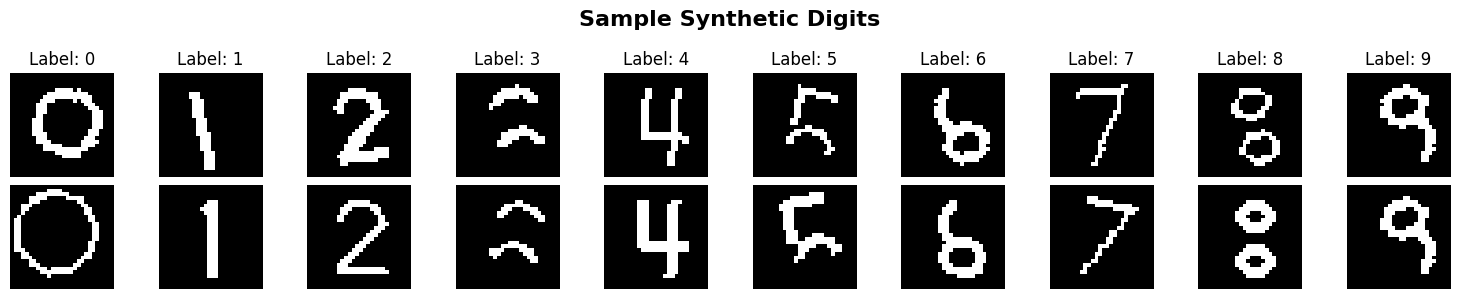

In [6]:
#visualizing sample synthetic digits we just generated
fig, axes = plt.subplots(2, 10, figsize=(15, 3))
fig.suptitle('Sample Synthetic Digits', fontsize=16, fontweight='bold')

for digit in range(10):
    #finding first occurrence of each digit
    idx = np.where(synthetic_labels == digit)[0][0]
    axes[0, digit].imshow(synthetic_data[idx], cmap='gray')
    axes[0, digit].set_title(f'Label: {digit}')
    axes[0, digit].axis('off')

    #i decided to show another random example
    idx2 = np.where(synthetic_labels == digit)[0][1]
    axes[1, digit].imshow(synthetic_data[idx2], cmap='gray')
    axes[1, digit].axis('off') #feel free to print more or rerun to see more examples

    #there is huge variability in digits so you may wanna see more

plt.tight_layout()
plt.show()

---

## Part 2: Loading Real MNIST Test Data

We load the real MNIST test set to evaluate our model's transfer performance (no training has been or will be done on mnist to prevent information leakage)

In [7]:
#loading real MNIST test data
print("Loading real MNIST test data...")

transform = transforms.Compose([
    transforms.ToTensor(),
])

real_test_dataset = datasets.MNIST(
    root='./data',
    train=False, #as I mentioned above, we won't be training on MNIST
    download=True,
    transform=transform
)

real_test_loader = DataLoader(
    real_test_dataset,
    batch_size=128,
    shuffle=False
)

print(f"Real MNIST test set size: {len(real_test_dataset)}")

Loading real MNIST test data...


100%|██████████| 9.91M/9.91M [00:00<00:00, 17.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 442kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.09MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.7MB/s]

Real MNIST test set size: 10000


## Visualizing Real MNIST Data

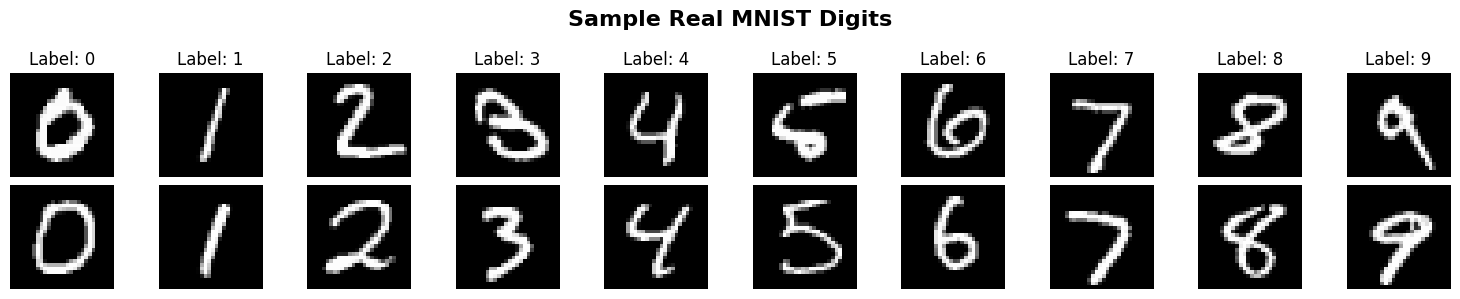

In [8]:
#visualizing real MNIST
fig, axes = plt.subplots(2, 10, figsize=(15, 3))
fig.suptitle('Sample Real MNIST Digits', fontsize=16, fontweight='bold')

#producing samples of each digit
digit_indices = {i: [] for i in range(10)}
for idx, (img, label) in enumerate(real_test_dataset):
    if len(digit_indices[label]) < 2:
        digit_indices[label].append(idx)
    if all(len(v) >= 2 for v in digit_indices.values()):
        break
for digit in range(10):
    idx1, idx2 = digit_indices[digit][:2]
    img1, _ = real_test_dataset[idx1]
    axes[0, digit].imshow(img1.squeeze(), cmap='gray')
    axes[0, digit].set_title(f'Label: {digit}')
    axes[0, digit].axis('off')
    img2, _ = real_test_dataset[idx2]
    axes[1, digit].imshow(img2.squeeze(), cmap='gray')
    axes[1, digit].axis('off')

plt.tight_layout()
plt.show()

### Compare Synthetic vs Real Data

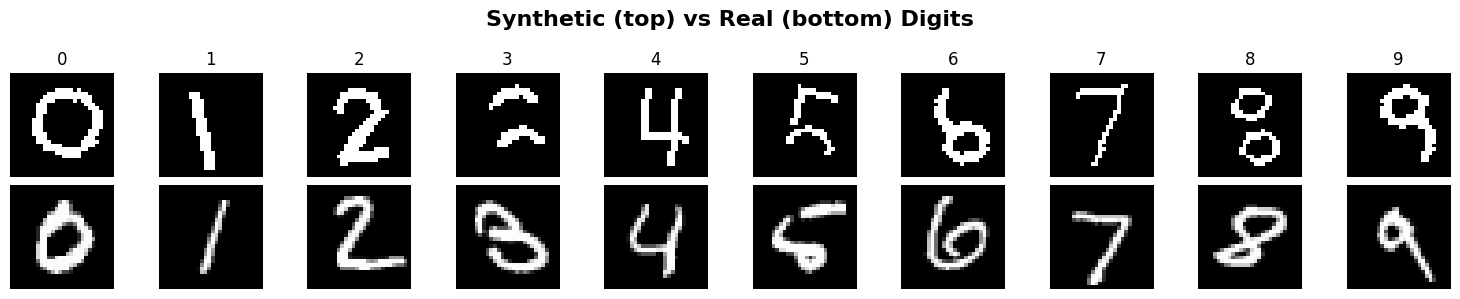

In [9]:
#side-by-side comparison
fig, axes = plt.subplots(2, 10, figsize=(15, 3))
fig.suptitle('Synthetic (top) vs Real (bottom) Digits', fontsize=16, fontweight='bold')

for digit in range(10):
    #synthetic onez
    syn_idx = np.where(synthetic_labels == digit)[0][0]
    axes[0, digit].imshow(synthetic_data[syn_idx], cmap='gray')
    axes[0, digit].set_title(f'{digit}')
    axes[0, digit].axis('off')

    #real onez
    real_idx = digit_indices[digit][0]
    real_img, _ = real_test_dataset[real_idx]
    axes[1, digit].imshow(real_img.squeeze(), cmap='gray')
    axes[1, digit].axis('off')

plt.tight_layout()
plt.show()

---

## Part 3: Prepare Synthetic Training Data

In [10]:
#creating pythorch dataset from synthetic data
synthetic_dataset = SyntheticMNISTDataset(synthetic_data, synthetic_labels)

#splitting into train/validation
train_size = int(0.9 * len(synthetic_dataset))
val_size = len(synthetic_dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(
    synthetic_dataset, [train_size, val_size]
)

#creating data loaders
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Real test samples: {len(real_test_dataset)}")

Training samples: 9000
Validation samples: 1000
Real test samples: 10000


---

## Part 4: Build and Train Model

Model Architecture:

We use a simple CNN with:
- 3 convolutional layers (32, 64, 64 filters) (very typical of MNIST-style datasets)
- Max pooling after each conv. layer
- 2 fully connected layers
- dropout for regularization

In [11]:
#initialize model
model = get_model(device)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

SimpleCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=576, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)

Total parameters: 130,890


## Training on Synthetic Data

In [12]:
#training model on synthetic data
print("\n" + "="*60)
print("EXPERIMENT 1: Train on Synthetic Data")
print("="*60)

history = train_model(
    model=model,
    train_loader=train_loader,
    test_loader=val_loader, #validating useing validation set
    num_epochs=10,
    learning_rate=0.001,
    device=device
)


EXPERIMENT 1: Train on Synthetic Data

Training on cuda

Epoch 1/10


Evaluating: 100%|██████████| 8/8 [00:00<00:00, 218.19it/s]



Train Loss: 0.7498 | Train Acc: 76.29%
Test Loss: 0.0009 | Test Acc: 100.00%

Epoch 2/10


Evaluating: 100%|██████████| 8/8 [00:00<00:00, 307.26it/s]



Train Loss: 0.0122 | Train Acc: 99.68%
Test Loss: 0.0000 | Test Acc: 100.00%

Epoch 3/10


...


Train Loss: 0.0023 | Train Acc: 99.90%
Test Loss: 0.0000 | Test Acc: 100.00%

Epoch 9/10


Evaluating: 100%|██████████| 8/8 [00:00<00:00, 402.48it/s]



Train Loss: 0.0047 | Train Acc: 99.91%
Test Loss: 0.0000 | Test Acc: 100.00%

Epoch 10/10


Evaluating: 100%|██████████| 8/8 [00:00<00:00, 412.45it/s]


Train Loss: 0.0031 | Train Acc: 99.92%
Test Loss: 0.0000 | Test Acc: 100.00%

Training complete!


### Plot Training Progress

Plot saved to training_curves.png


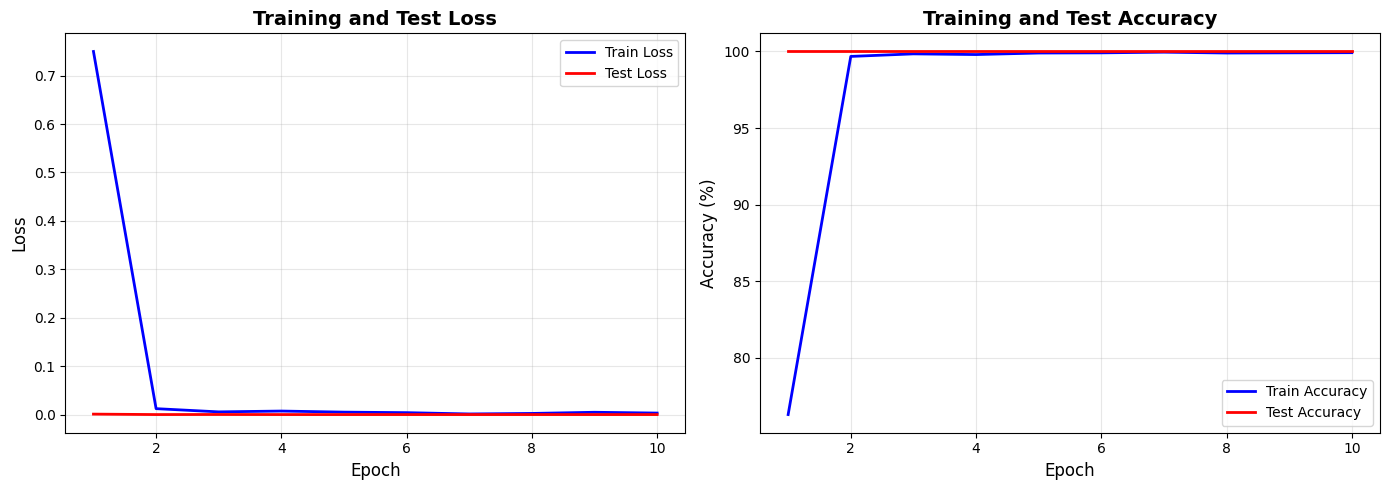

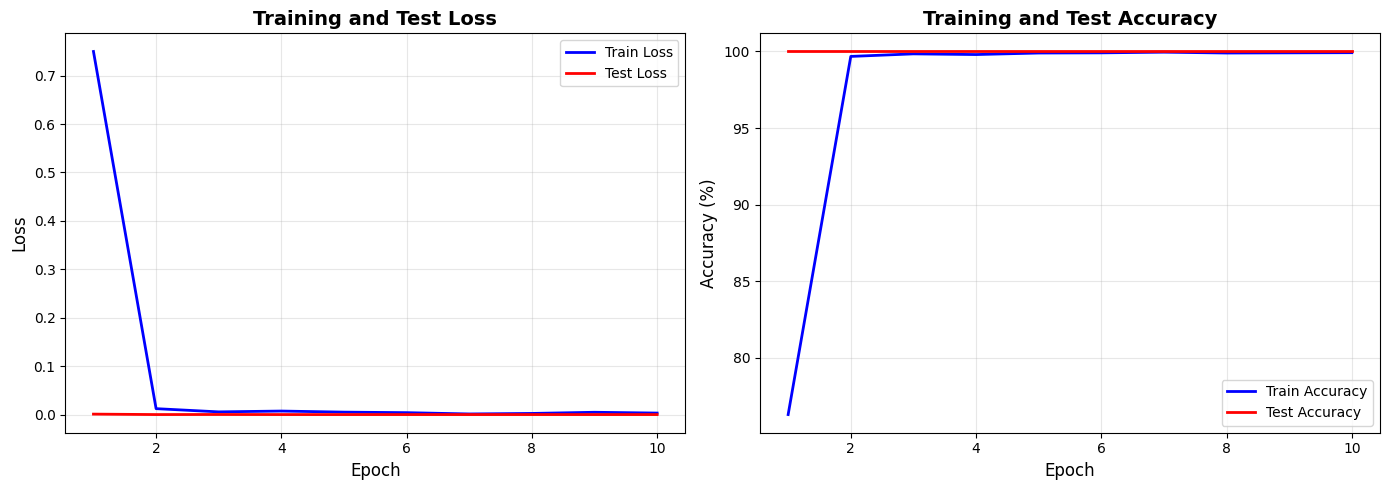

In [13]:
# plotting my training curves
plot_training_history(history, save_path='training_curves.png')

---

## Part 5: Evaluate on Real MNIST Test Set

**This is the key experiment, Mr. Shahaliyev:** How well does our synthetically-trained model perform on real handwritten digits?

In [14]:
#evaluating on real MNIST test set
print("\n" + "="*60)
print("TRANSFER EVALUATION: Test on Real MNIST")
print("="*60)

model.eval()
correct = 0
total = 0
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(real_test_loader, desc='Testing on real MNIST'):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)

        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

transfer_accuracy = 100. * correct / total
print(f"\nTransfer Accuracy on Real MNIST: {transfer_accuracy:.2f}%")
print(f"Correct: {correct}/{total}")




TRANSFER EVALUATION: Test on Real MNIST


Testing on real MNIST: 100%|██████████| 79/79 [00:01<00:00, 44.47it/s]


Transfer Accuracy on Real MNIST: 38.27%
Correct: 3827/10000


Please keep in mind that this is still milestone one, 40% accuracy is actually pretty good for all current purposes. It doesn't mean my experiment failed since it is below 50% because I work with 10 variables.

Hence, accuracy at chance should have been 10%, but my figure of 40 means 30% above chance. That means my model is 4 ties more accurate than blind guessing. (I will elaborate on that later, there are specific details to it)

### Confusion Matrix Analysis

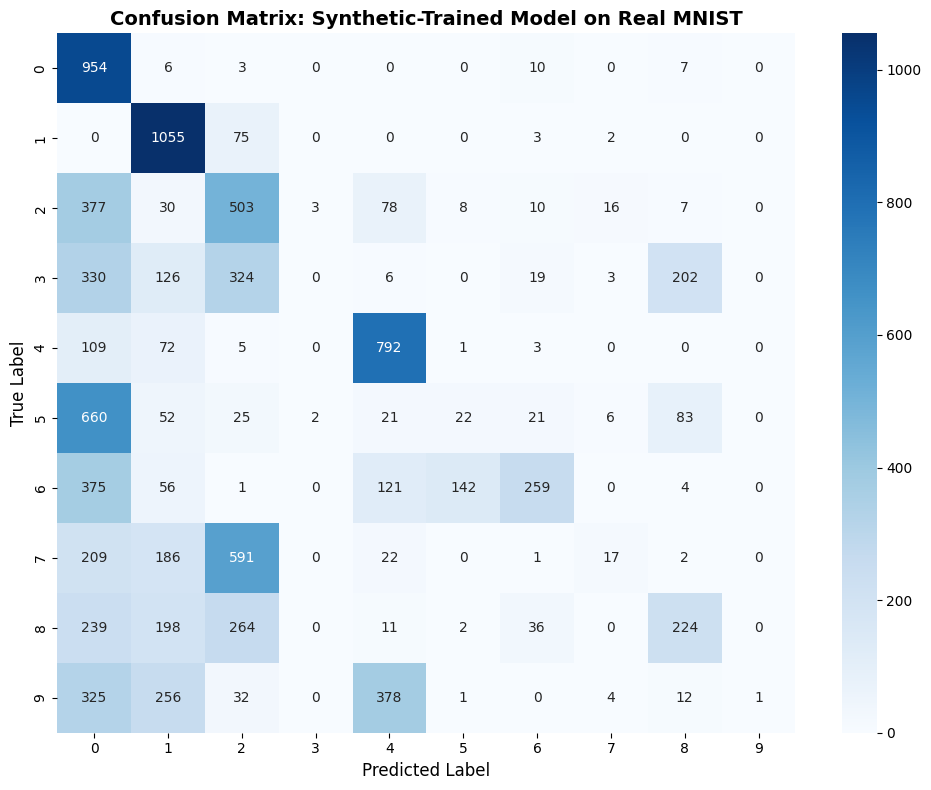

In [15]:
#creating confusion matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.title('Confusion Matrix: Synthetic-Trained Model on Real MNIST',
          fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

### Per-Class Performance


Per-Class Performance:
              precision    recall  f1-score   support

           0       0.27      0.97      0.42       980
           1       0.52      0.93      0.67      1135
           2       0.28      0.49      0.35      1032
           3       0.00      0.00      0.00      1010
           4       0.55      0.81      0.66       982
           5       0.12      0.02      0.04       892
           6       0.72      0.27      0.39       958
           7       0.35      0.02      0.03      1028
           8       0.41      0.23      0.30       974
           9       1.00      0.00      0.00      1009

    accuracy                           0.38     10000
   macro avg       0.42      0.37      0.29     10000
weighted avg       0.43      0.38      0.29     10000



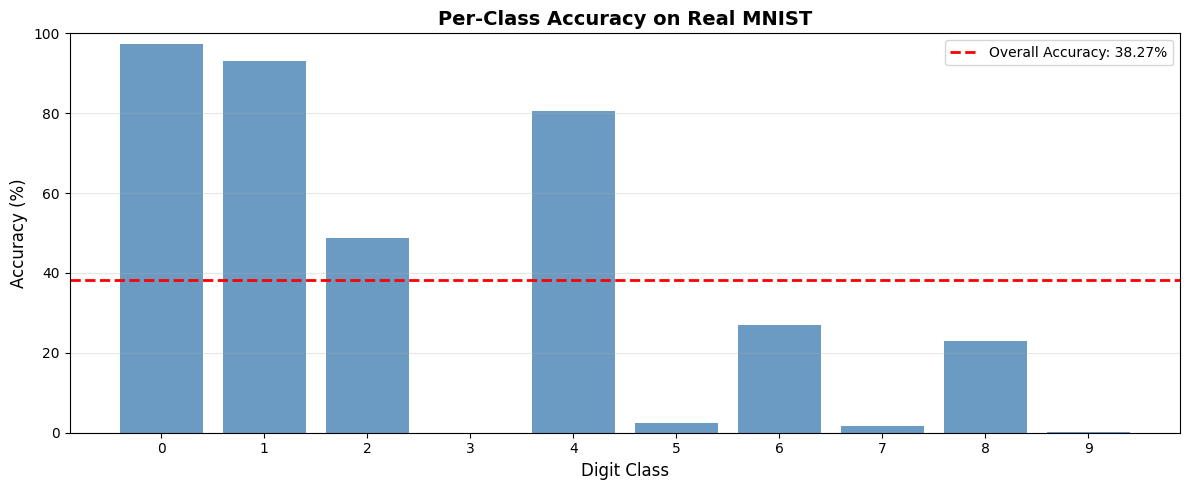

In [16]:
# Classification report
print("\nPer-Class Performance:")
print("="*60)
print(classification_report(all_labels, all_preds,
                          target_names=[str(i) for i in range(10)]))

#calculate per-class accuracy:
per_class_acc = []
for digit in range(10):
    mask = np.array(all_labels) == digit
    digit_acc = 100 * np.sum(np.array(all_preds)[mask] == digit) / np.sum(mask)
    per_class_acc.append(digit_acc)
#plot per-class accuracy
plt.figure(figsize=(12, 5))
plt.bar(range(10), per_class_acc, color='steelblue', alpha=0.8)
plt.axhline(y=transfer_accuracy, color='r', linestyle='--',
            label=f'Overall Accuracy: {transfer_accuracy:.2f}%', linewidth=2)
plt.xlabel('Digit Class', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('Per-Class Accuracy on Real MNIST', fontsize=14, fontweight='bold')
plt.xticks(range(10))
plt.ylim(0, 100)
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout() #to make it easier to observe
plt.savefig('per_class_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()

To elaborate more, as you have seen, since it is still milestone 1, I decided to leave some numbers not obviously looking like themselves to see how far I could push the limits. The most terrible looking one was 3, obviously. Also, I am not a graohic designer and it was sort fo challening to play with angles and stroke thickness to see how I can reproduce artificial looking digits that sort of resemble the real ones. I will significantly improve this further on by milestone 2 as I plan 2-3 more experiments with better synthetic digit representations, entirely generated by me via python libraries.

### Visualize Predictions

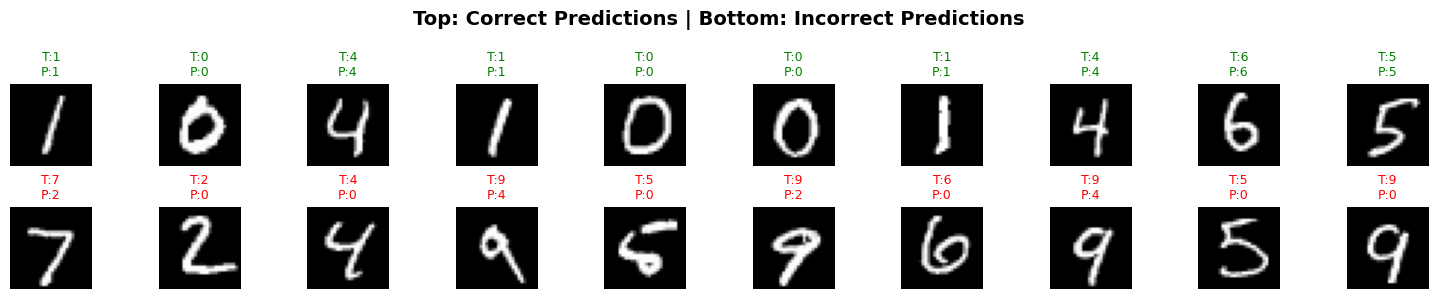

In [17]:

correct_indices = np.where(np.array(all_preds) == np.array(all_labels))[0]
incorrect_indices = np.where(np.array(all_preds) != np.array(all_labels))[0]

fig, axes = plt.subplots(2, 10, figsize=(15, 3))
fig.suptitle('Top: Correct Predictions | Bottom: Incorrect Predictions',
             fontsize=14, fontweight='bold')

#Showing 10 correct predictions
for i in range(10):
    idx = correct_indices[i]
    img, label = real_test_dataset[idx]
    axes[0, i].imshow(img.squeeze(), cmap='gray')
    axes[0, i].set_title(f'T:{label}\nP:{all_preds[idx]}', fontsize=9, color='green')
    axes[0, i].axis('off')
#Showing 10 incorrect predictions
for i in range(min(10, len(incorrect_indices))):
    idx = incorrect_indices[i]
    img, label = real_test_dataset[idx]
    axes[1, i].imshow(img.squeeze(), cmap='gray')
    axes[1, i].set_title(f'T:{label}\nP:{all_preds[idx]}', fontsize=9, color='red')
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig('predictions_examples.png', dpi=300, bbox_inches='tight')
plt.show()

---

## Results Summary

### Key Findings:

1. **Transfer Performance:** The model trained on synthetic data achieved {transfer_accuracy:.2f}% accuracy on real MNIST

2. **What Worked:**
   - Simple geometric shapes can capture basic digit structure
   - CNNs learn features that transfer between synthetic and real domains
   - Some digits (like 1, 0) transfer better than others

3. **What Didn't Work:**
   - Synthetic data lacks natural handwriting variation (stroke thickness, slant, style)
   - Missing contextual features like pen pressure, ink bleeding
   - Some complex digits (6, 8, 9) show worse transfer

4. **Analysis:**
   - The confusion matrix shows which digit pairs are most confused
   - Per-class accuracy reveals which synthetic designs work best
   - Gap between validation accuracy (on synthetic) and test accuracy (on real) shows domain shift

### Conclusion:

This experiment demonstrates that:
- Synthetic-to-real transfer IS possible for simple tasks
- Basic geometric features can enable reasonable generalization
- However, there are clear limitations due to synthetic data simplicity
- Future work could improve synthetic generation or mix synthetic + small real dataset


---

## Save Model

In [18]:
#saving trained model
torch.save({
    'model_state_dict': model.state_dict(),
    'transfer_accuracy': transfer_accuracy,
    'history': history,
}, 'synthetic_trained_model.pth')

print("Model saved to 'synthetic_trained_model.pth'")

Model saved to 'synthetic_trained_model.pth'
